# Statistics every analyst needs

Most bad business decisions made "from the data" come down to a handful of
statistical mistakes: trusting an average that hides the real story, reading
noise as a trend, or confusing correlation with cause. This notebook walks
through the ideas that prevent them:

1. Mean vs. median, and why skewed data needs care
2. How much a number from a sample can be trusted (the central limit theorem)
3. Confidence intervals, by formula and by bootstrap
4. What a p-value actually tells you, and how often it lies
5. Simpson's paradox: when the overall trend is the opposite of every subgroup

Sections 1 to 4 use simulated data so we know the true answer. Section 5 uses
a real, published medical study.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

rng = np.random.default_rng(42)
plt.rcParams.update({"figure.figsize": (9, 4), "axes.spines.top": False, "axes.spines.right": False})

## 1. The average customer doesn't exist

Money is almost always skewed: most orders are small and a few are huge.
Here are 10,000 simulated order values.

Mean order:   $49.49
Median order: $32.73
Share of orders below the mean: 68%
Revenue from the top 10% of orders: 36%


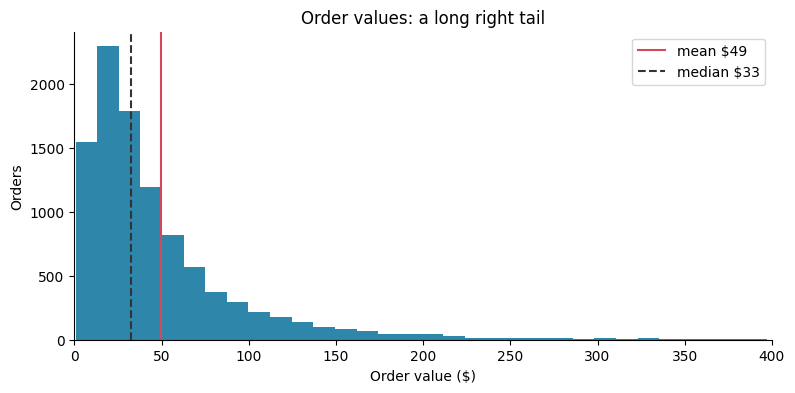

In [ ]:
orders = rng.lognormal(mean=3.5, sigma=0.9, size=10_000)

print(f"Mean order:   ${orders.mean():,.2f}")
print(f"Median order: ${np.median(orders):,.2f}")
print(f"Share of orders below the mean: {(orders < orders.mean()).mean():.0%}")
print(f"Revenue from the top 10% of orders: {np.sort(orders)[-1000:].sum() / orders.sum():.0%}")

fig, ax = plt.subplots()
ax.hist(orders, bins=100, color="#2e86ab")
ax.axvline(orders.mean(), color="#d1495b", label=f"mean ${orders.mean():.0f}")
ax.axvline(np.median(orders), color="#333", linestyle="--", label=f"median ${np.median(orders):.0f}")
ax.set(title="Order values: a long right tail", xlabel="Order value ($)", ylabel="Orders", xlim=(0, 400))
ax.legend();

The mean is pulled up by the big orders, so most customers spend *less* than
"the average customer". Rules of thumb:

- Report the **median** for "what a typical customer does".
- Report the **mean** when you need totals (mean × customers = revenue).
- When the two are far apart, show the distribution, not just one number.

## 2. How much can a sample tell you?

We rarely see everyone. We see a sample, like last week's 200 orders, and
want to know the true average. The **central limit theorem** says that if you
took many samples, their averages would form a bell curve around the truth,
even when the data itself is skewed like ours. The width of that bell is the
**standard error**, and it shrinks with the square root of the sample size.

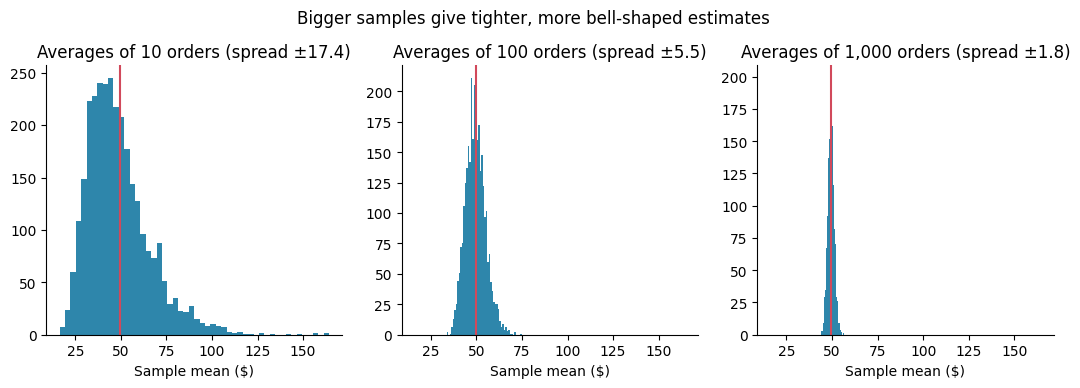

In [ ]:
true_mean = orders.mean()
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharex=True)
for ax, n in zip(axes, [10, 100, 1000], strict=True):
    sample_means = [rng.choice(orders, n).mean() for _ in range(3000)]
    ax.hist(sample_means, bins=50, color="#2e86ab")
    ax.axvline(true_mean, color="#d1495b")
    ax.set(title=f"Averages of {n:,} orders (spread ±{np.std(sample_means):.1f})", xlabel="Sample mean ($)")
fig.suptitle("Bigger samples give tighter, more bell-shaped estimates", y=1.04);

Going from 100 to 1,000 orders made the estimate about three times tighter,
not ten times (√10 ≈ 3.2). That square root is why "just collect more data"
gets expensive fast: halving your uncertainty takes four times the data.

## 3. Confidence intervals

A 95% confidence interval is a range built so that, if you repeated the
study many times, 95% of those ranges would contain the true value. There
are two common ways to build one.

**By formula:** mean ± 1.96 × standard error. Quick, and fine when the
sample is large enough for the bell curve to kick in.

**By bootstrap:** resample your own data with replacement thousands of
times and see how much the answer moves. It needs no formula, so it works
for medians, ratios and anything else you can compute.

In [ ]:
sample = rng.choice(orders, 200)

se = sample.std(ddof=1) / np.sqrt(len(sample))
formula_ci = (sample.mean() - 1.96 * se, sample.mean() + 1.96 * se)

boot_means = [rng.choice(sample, len(sample)).mean() for _ in range(5000)]
boot_medians = [np.median(rng.choice(sample, len(sample))) for _ in range(5000)]

print(f"True mean ${true_mean:.2f}, true median ${np.median(orders):.2f}\n")
print(f"Sample mean ${sample.mean():.2f}")
print(f"  formula 95% CI:   ${formula_ci[0]:.2f} to ${formula_ci[1]:.2f}")
print(f"  bootstrap 95% CI: ${np.percentile(boot_means, 2.5):.2f} to ${np.percentile(boot_means, 97.5):.2f}")
print(f"Sample median ${np.median(sample):.2f}")
print(f"  bootstrap 95% CI: ${np.percentile(boot_medians, 2.5):.2f} to ${np.percentile(boot_medians, 97.5):.2f}")

True mean $49.49, true median $32.73

Sample mean $52.51
  formula 95% CI:   $42.89 to $62.14
  bootstrap 95% CI: $43.90 to $62.96
Sample median $31.77
  bootstrap 95% CI: $27.88 to $37.25


Does "95%" really mean 95%? We can check, because we know the truth: draw
1,000 samples, build an interval from each, and count how many catch the
true mean.

In [ ]:
hits = 0
for _ in range(1000):
    s = rng.choice(orders, 200)
    half_width = 1.96 * s.std(ddof=1) / np.sqrt(len(s))
    hits += abs(s.mean() - true_mean) <= half_width
print(f"Intervals that contained the true mean: {hits / 10:.1f}%")

Intervals that contained the true mean: 92.8%


Close to 95%, but a little short. With skewed data and small samples the
formula interval tends to be slightly too narrow, which is one reason to
prefer the bootstrap there.

## 4. What a p-value does and doesn't tell you

A p-value answers one narrow question: *if there were really no difference,
how surprising would a result like this be?* A p-value of 0.03 means a gap
this big would show up by chance about 3% of the time when nothing is going
on. It is **not** the chance the result is a fluke, and it says nothing about
whether the difference is big enough to matter.

The best way to feel this is an **A/A test**: split users into two groups
that get exactly the same experience, and test for a difference anyway.

A/A tests 'significant' at p < 0.05: 5.1%


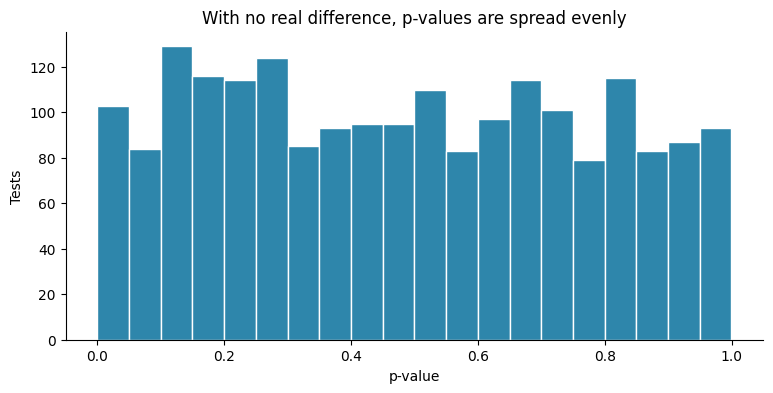

In [ ]:
p_values = []
for _ in range(2000):
    a = rng.choice(orders, 500)
    b = rng.choice(orders, 500)  # same distribution: there is no real difference
    p_values.append(stats.ttest_ind(a, b, equal_var=False).pvalue)
p_values = np.array(p_values)

print(f"A/A tests 'significant' at p < 0.05: {(p_values < 0.05).mean():.1%}")

fig, ax = plt.subplots()
ax.hist(p_values, bins=20, color="#2e86ab", edgecolor="white")
ax.set(title="With no real difference, p-values are spread evenly", xlabel="p-value", ylabel="Tests");

About 1 in 20 tests "finds" a difference that isn't there. That's what a
5% threshold means. It becomes a real problem when you test many things at
once: check 20 metrics and you should expect one false win. The fixes are to
decide your main metric before you look, and to be more demanding (a smaller
threshold, or a correction like Bonferroni) when you test many.

## 5. Simpson's paradox: a real medical example

In 1986 a study in the *British Medical Journal* (Charig et al.) compared two
treatments for kidney stones. Here are its success counts.

In [ ]:
kidney = pd.DataFrame({
    "treatment": ["A (open surgery)", "A (open surgery)", "B (keyhole)", "B (keyhole)"],
    "stone_size": ["small", "large", "small", "large"],
    "successes": [81, 192, 234, 55],
    "patients": [87, 263, 270, 80],
})
kidney["success_rate"] = kidney.successes / kidney.patients

overall = kidney.groupby("treatment")[["successes", "patients"]].sum()
overall["success_rate"] = overall.successes / overall.patients
print("Overall:")
print(overall.success_rate.map("{:.0%}".format).to_string())
print("\nBy stone size:")
print(kidney.pivot(index="stone_size", columns="treatment", values="success_rate").map("{:.0%}".format))

Overall:
treatment
A (open surgery)    78%
B (keyhole)         83%

By stone size:
treatment  A (open surgery) B (keyhole)
stone_size                             
large                   73%         69%
small                   93%         87%


Treatment B looks better overall (83% vs 78%), yet **A is better for small
stones and better for large stones**. How?

Doctors gave the harder cases, large stones, to open surgery (A), and large
stones fail more often whatever you do. So A's overall number is dragged down
by *who it was given to*, not by how well it works. Stone size is a
**confounder**: it affects both the choice of treatment and the outcome.

In [ ]:
mix = kidney.pivot(index="treatment", columns="stone_size", values="patients")
print("Share of each treatment's patients with large stones:")
print((mix["large"] / mix.sum(axis=1)).map("{:.0%}".format).to_string())

Share of each treatment's patients with large stones:
treatment
A (open surgery)    75%
B (keyhole)         23%


The same trap shows up everywhere in business data. A sales channel can look
worse overall only because it serves harder customers. A feature can look
like it boosts retention only because keen users find it first. Before
trusting a comparison, ask what else differs between the groups.

## Takeaways

- Skewed data: report the median for "typical", the mean for totals.
- Uncertainty shrinks with √n. Always give a range, not just a number.
- Bootstrap when there's no easy formula.
- p < 0.05 still means 1 in 20 false alarms. Pick your metric before you look.
- Compare like with like. Look for confounders before claiming a cause.